# Generator Sanity Check: GMM vs cGAN vs TVAE

Quick visual + 3 key metrics to confirm generated samples match real data.

**Rule of thumb:**
- PCA/t-SNE: generated points should **overlap** real clusters
- MAE < 0.05 ✅ | Pearson r > 0.85 ✅ | Wasserstein < 0.05 ✅

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pickle
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import wasserstein_distance
from scipy.stats import pearsonr

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.titlesize': 11, 'figure.facecolor': 'white'})
print('✅ imports OK')

✅ imports OK


In [2]:
# ── Load real data ────────────────────────────────────────────────────────────
data    = np.load('test_data.npz')
X_real  = data['X_test'].astype(np.float32)
y_real  = data['y_test']

try:
    with open('saved_state/feature_cols.pkl', 'rb') as f:
        feat_cols = pickle.load(f)
except:
    feat_cols = [f'f{i}' for i in range(X_real.shape[1])]

try:
    with open('saved_state/reverse_label_map.pkl', 'rb') as f:
        rev = pickle.load(f)
    class_names = {v: k for k, v in rev.items()}
except:
    class_names = {i: str(i) for i in np.unique(y_real)}

print(f'Real data: {X_real.shape[0]:,} × {X_real.shape[1]} features')
for code, name in sorted(class_names.items()):
    print(f'  [{code}] {name:<32} {int((y_real==code).sum()):>6,} samples')

Real data: 100,000 × 39 features
  [0] Benign                               57 samples
  [1] C&C-HeartBeat                        11 samples
  [2] DDoS                             25,055 samples
  [3] Okiru                            25,028 samples
  [4] PartOfAHorizontalPortScan        49,849 samples


In [3]:
# ── Load generators ───────────────────────────────────────────────────────────
from gateway.gmm_generator import GMMGenerator
gmm = GMMGenerator.load()
all_classes    = list(gmm.gmms.keys())
benign_label   = 'Benign'
attack_classes = [c for c in all_classes if c != benign_label]
print(f'GMM classes: {all_classes}')

tvae_ok = False
try:
    from gateway.load_tvae import load_tvae
    tvae_model, tvae_le, _, _, _ = load_tvae()
    tvae_ok = True
    print('TVAE ✅')
except Exception as e:
    print(f'TVAE not available: {e}')

cgan_ok = False
try:
    from gateway.utils import load_cgan
    cgan_model, cgan_le, _, _, _ = load_cgan()
    cgan_ok = True
    print('cGAN ✅')
except Exception as e:
    print(f'cGAN not available: {e}')

GMM classes: ['Benign', 'C&C-HeartBeat', 'DDoS', 'Okiru', 'PartOfAHorizontalPortScan']
TVAE ✅
cGAN ✅


In [4]:
# ── Generation helpers ────────────────────────────────────────────────────────
from gateway.utils import name_to_compact_id

N = 500  # samples per generator per class

def gen_gmm(cls, n=N):
    return gmm.sample_class(cls, n)

def gen_tvae(cls, n=N):
    if not tvae_ok: return None
    cid = name_to_compact_id(cls, tvae_le)
    lbl = torch.full((n,), cid, dtype=torch.long)
    with torch.no_grad():
        z = torch.randn(n, tvae_model.latent_dim)
        return tvae_model.decode(z, lbl).numpy().clip(0, 1).astype('float32')

def gen_cgan(cls, n=N, blend=0.1):
    """Pure blend: (1-alpha)*GMM + alpha*cGAN"""
    if not cgan_ok: return None
    X_gmm = gmm.sample_class(cls, n)
    cid   = name_to_compact_id(cls, cgan_le)
    lbl   = torch.full((n,), cid, dtype=torch.long)
    with torch.no_grad():
        z     = torch.randn(n, cgan_model.latent_dim)
        X_gan = cgan_model.generate(lbl, z).numpy()
    return np.clip((1-blend)*X_gmm + blend*X_gan, 0, 1).astype('float32')

# ── 3 key metrics ─────────────────────────────────────────────────────────────
def metrics(X_r, X_g):
    """MAE, Pearson r, mean Wasserstein. All vs feature means."""
    if X_g is None or len(X_g) < 5:
        return None
    mae = float(np.abs(X_r.mean(0) - X_g.mean(0)).mean())
    rm, gm = X_r.mean(0), X_g.mean(0)
    r = float(pearsonr(rm, gm)[0]) if rm.std() > 1e-9 and gm.std() > 1e-9 else 0.0
    ws = float(np.mean([wasserstein_distance(X_r[:,f], X_g[:,f]) for f in range(X_r.shape[1])]))
    return dict(mae=mae, r=r, ws=ws)

def fmt(m):
    if m is None: return 'N/A'
    mae_ok = '✅' if m['mae'] < 0.05 else ('⚠️' if m['mae'] < 0.10 else '❌')
    r_ok   = '✅' if m['r']   > 0.85 else ('⚠️' if m['r']   > 0.70 else '❌')
    ws_ok  = '✅' if m['ws']  < 0.05 else ('⚠️' if m['ws']  < 0.10 else '❌')
    return (f"MAE={m['mae']:.4f}{mae_ok}  r={m['r']:.4f}{r_ok}  "
            f"WS={m['ws']:.4f}{ws_ok}")

print('Helpers ready ✅')

Helpers ready ✅


## 1. Per-Class Metrics — Quick Sanity Table

In [5]:
print(f'{"-"*75}')
print(f'{"Class":<28} {"Generator":<8}  Metrics')
print(f'{"-"*75}')

for code, name in sorted(class_names.items()):
    mask  = y_real == code
    X_cls = X_real[mask]
    if len(X_cls) < 10:
        print(f'{name:<28} — skipped (only {len(X_cls)} real samples)')
        continue
    # use all real samples but cap at 5000 for speed
    X_r = X_cls[:5000]
    for gen_name, X_g in [
        ('GMM',  gen_gmm(name)),
        ('TVAE', gen_tvae(name)),
        ('cGAN', gen_cgan(name, blend=0.1)),
    ]:
        m = metrics(X_r, X_g)
        label = name[:27] if gen_name == 'GMM' else ''
        print(f'{label:<28} {gen_name:<8}  {fmt(m)}')
    print()

print(f'{"-"*75}')
print('✅ = good  ⚠️ = marginal  ❌ = needs attention')

---------------------------------------------------------------------------
Class                        Generator  Metrics
---------------------------------------------------------------------------
Benign                       GMM       MAE=0.0174✅  r=0.9932✅  WS=0.0297✅
                             TVAE      MAE=0.1231❌  r=0.5495❌  WS=0.1951❌
                             cGAN      MAE=0.0513⚠️  r=0.9685✅  WS=0.0679⚠️

C&C-HeartBeat                GMM       MAE=0.0162✅  r=0.9929✅  WS=0.0186✅
                             TVAE      MAE=0.0918⚠️  r=0.6925❌  WS=0.1168❌
                             cGAN      MAE=0.0265✅  r=0.9872✅  WS=0.0329✅

DDoS                         GMM       MAE=0.0094✅  r=0.9954✅  WS=0.0102✅
                             TVAE      MAE=0.0805⚠️  r=0.7316⚠️  WS=0.0828⚠️
                             cGAN      MAE=0.0370✅  r=0.9856✅  WS=0.0370✅

Okiru                        GMM       MAE=0.0090✅  r=0.9959✅  WS=0.0112✅
                             TVAE      MAE=0.0802⚠️

## 2. PCA 2D — Real vs Generated

Each subplot: **blue = real**, **coloured = generated**. Overlap is good.

PCA variance explained: PC1=61.7%  PC2=35.2%


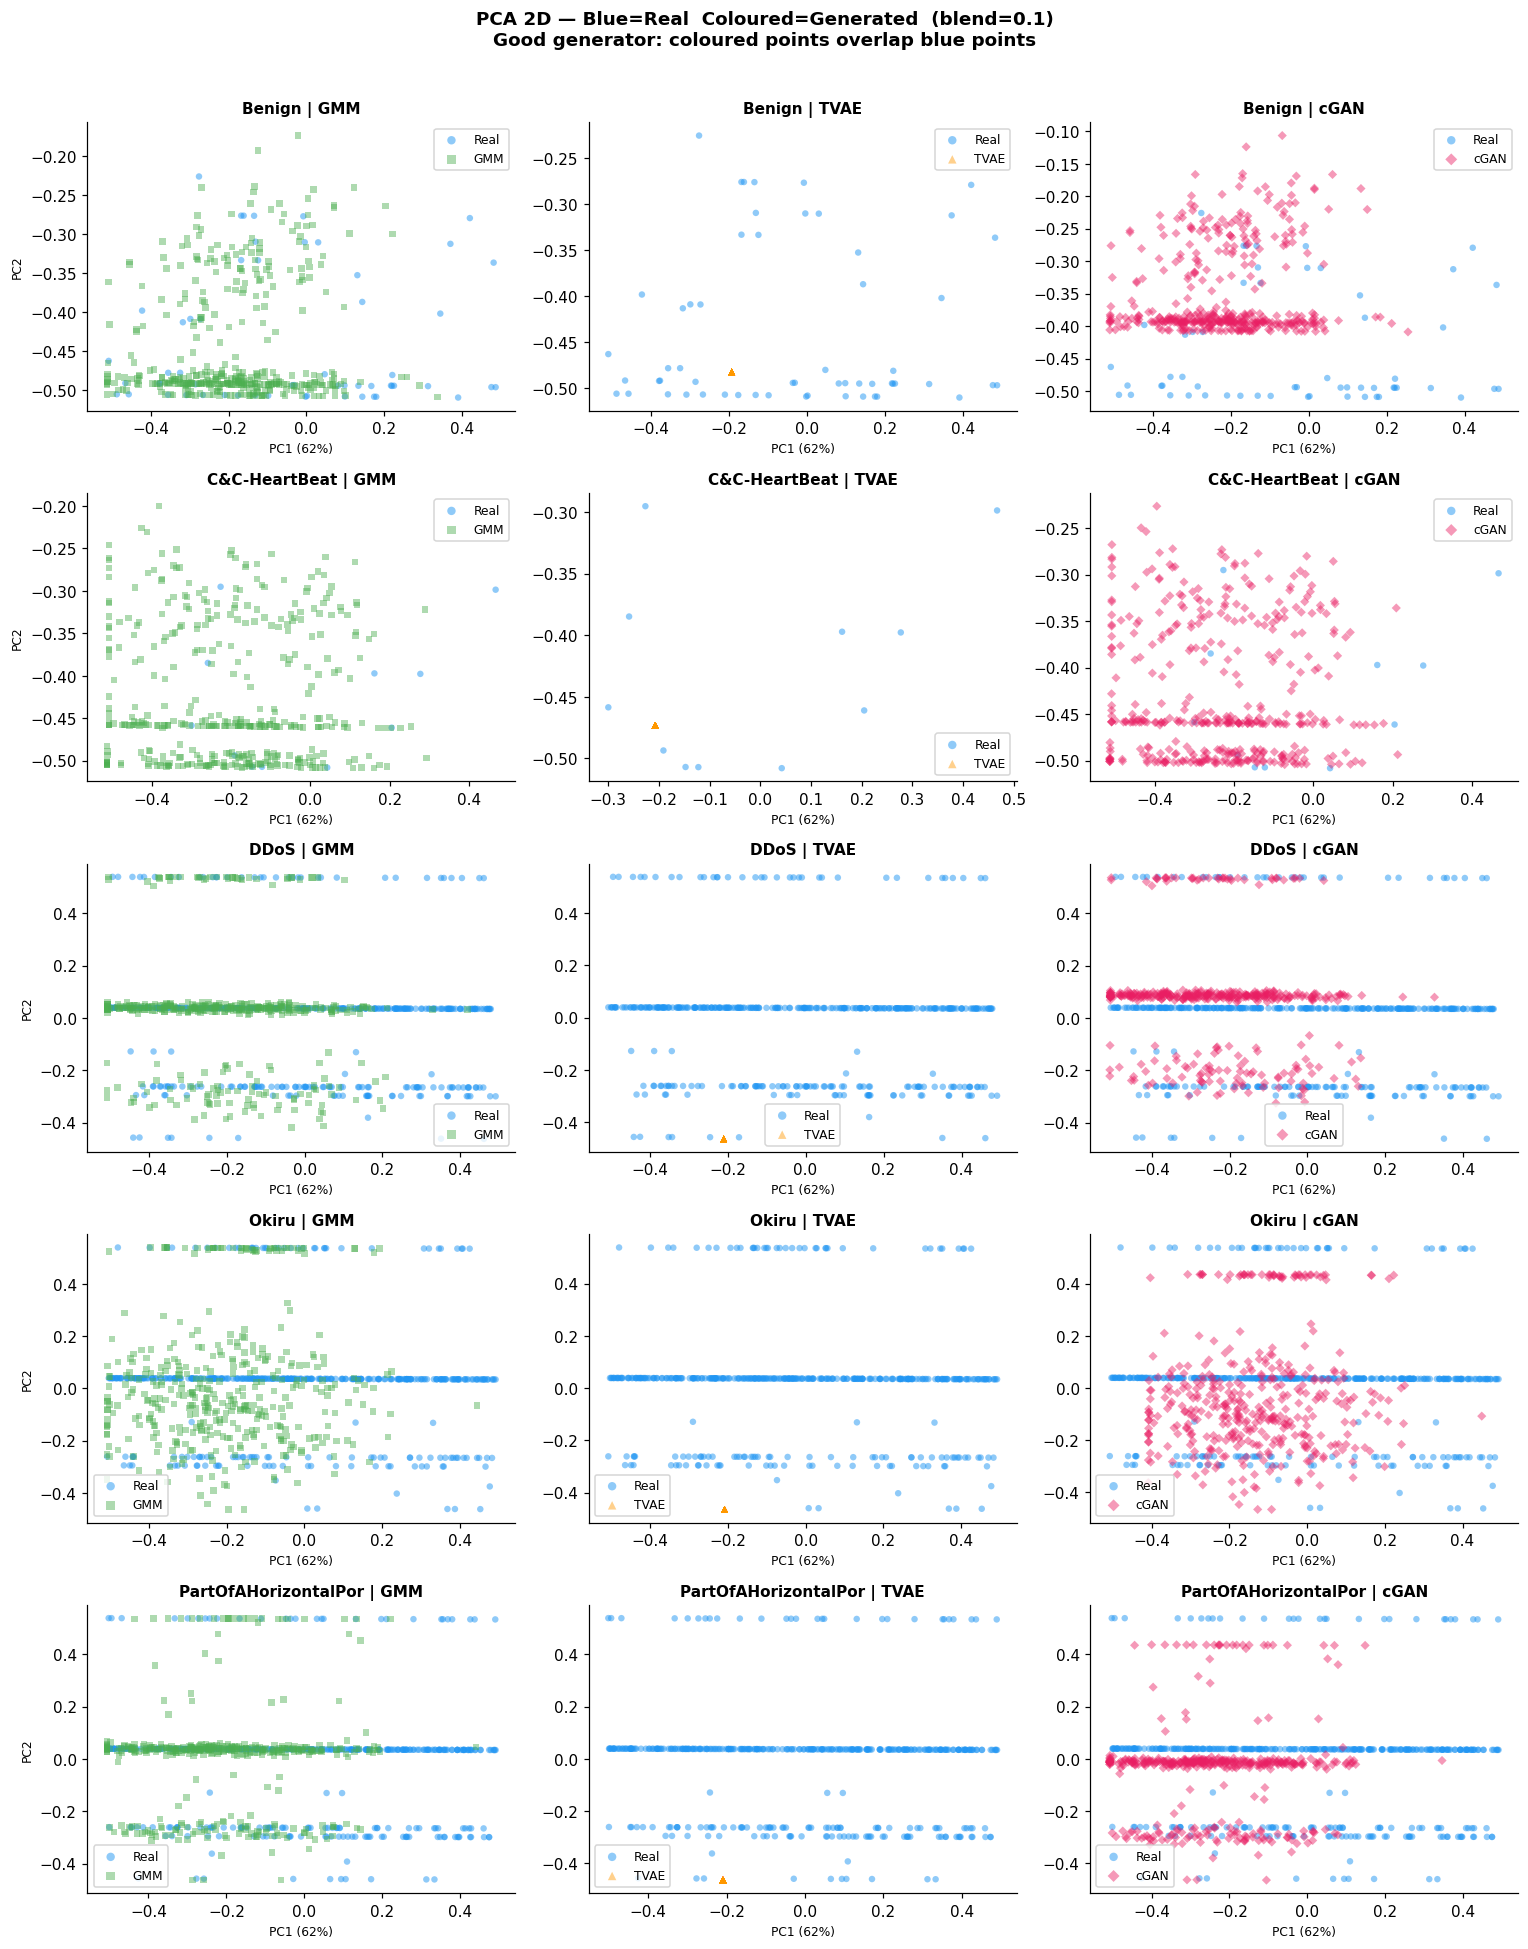

💡 If blue and coloured overlap → generator is good.


In [6]:
# Fit PCA on ALL real data (subsample for speed)
rng    = np.random.default_rng(42)
idx_r  = rng.choice(len(X_real), size=min(3000, len(X_real)), replace=False)
pca    = PCA(n_components=2, random_state=42)
pca.fit(X_real[idx_r])
ev     = pca.explained_variance_ratio_
print(f'PCA variance explained: PC1={ev[0]*100:.1f}%  PC2={ev[1]*100:.1f}%')

BLEND  = 0.1   # ← change this to explore hybrid blend
N_VIZ  = 400

# For each class: GMM / TVAE / cGAN vs Real
classes_to_plot = [name for code, name in sorted(class_names.items())
                   if int((y_real == code).sum()) >= 10]

n_cls = len(classes_to_plot)
fig, axes = plt.subplots(n_cls, 3, figsize=(14, 3.5*n_cls), squeeze=False)
gen_labels  = ['GMM', 'TVAE', 'cGAN']
gen_colors  = ['#4CAF50', '#FF9800', '#E91E63']
gen_markers = ['s', '^', 'D']

for ri, cls_name in enumerate(classes_to_plot):
    code   = [k for k, v in class_names.items() if v == cls_name][0]
    X_cls  = X_real[y_real == code][:N_VIZ]
    Xr_pca = pca.transform(X_cls)

    gens = [
        gen_gmm(cls_name, N_VIZ),
        gen_tvae(cls_name, N_VIZ),
        gen_cgan(cls_name, N_VIZ, BLEND),
    ]

    for ci, (gen_name, X_g, col, mk) in enumerate(zip(gen_labels, gens, gen_colors, gen_markers)):
        ax = axes[ri][ci]
        # Real
        ax.scatter(Xr_pca[:,0], Xr_pca[:,1],
                   c='#2196F3', alpha=0.5, s=18, label='Real', edgecolors='none')
        # Generated
        if X_g is not None:
            Xg_pca = pca.transform(X_g)
            ax.scatter(Xg_pca[:,0], Xg_pca[:,1],
                       c=col, alpha=0.45, s=18, marker=mk,
                       label=gen_name, edgecolors='none')
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12)

        ax.set_title(f'{cls_name[:20]} | {gen_name}', fontsize=10, fontweight='bold')
        ax.set_xlabel(f'PC1 ({ev[0]*100:.0f}%)', fontsize=8)
        if ci == 0: ax.set_ylabel('PC2', fontsize=8)
        ax.legend(fontsize=8, markerscale=1.3)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle(f'PCA 2D — Blue=Real  Coloured=Generated  (blend={BLEND})\n'
             'Good generator: coloured points overlap blue points',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('💡 If blue and coloured overlap → generator is good.')

## 3. PCA — All Generators Together (per class)

See all 3 generators on one plot per class for easy comparison.

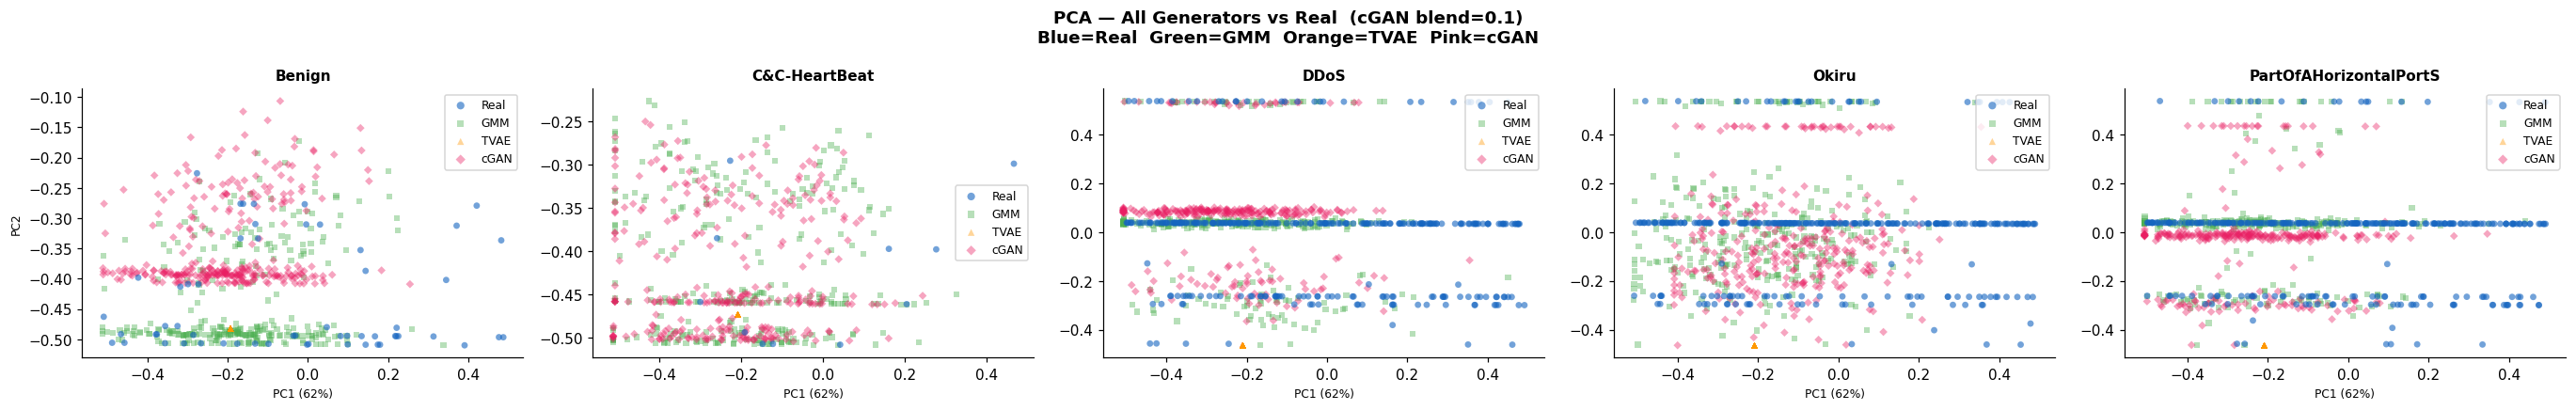

In [7]:
BLEND = 0.1
N_VIZ = 300

fig, axes = plt.subplots(1, n_cls, figsize=(5*n_cls, 4), squeeze=False)

for ci, cls_name in enumerate(classes_to_plot):
    code   = [k for k, v in class_names.items() if v == cls_name][0]
    X_cls  = X_real[y_real == code][:N_VIZ]
    Xr_pca = pca.transform(X_cls)
    ax     = axes[0][ci]

    ax.scatter(Xr_pca[:,0], Xr_pca[:,1],
               c='#1565C0', alpha=0.6, s=20, label='Real', edgecolors='none', zorder=3)

    for gen_name, X_g, col, mk in [
        ('GMM',  gen_gmm(cls_name, N_VIZ),           '#4CAF50', 's'),
        ('TVAE', gen_tvae(cls_name, N_VIZ),           '#FF9800', '^'),
        ('cGAN', gen_cgan(cls_name, N_VIZ, BLEND),   '#E91E63', 'D'),
    ]:
        if X_g is None: continue
        Xg_pca = pca.transform(X_g)
        ax.scatter(Xg_pca[:,0], Xg_pca[:,1],
                   c=col, alpha=0.4, s=16, marker=mk, label=gen_name, edgecolors='none')

    ax.set_title(cls_name[:22], fontsize=10, fontweight='bold')
    ax.set_xlabel(f'PC1 ({ev[0]*100:.0f}%)', fontsize=8)
    if ci == 0: ax.set_ylabel('PC2', fontsize=8)
    ax.legend(fontsize=8, markerscale=1.2)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle(f'PCA — All Generators vs Real  (cGAN blend={BLEND})\n'
             'Blue=Real  Green=GMM  Orange=TVAE  Pink=cGAN',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. t-SNE — Real vs Generated (for one class)

t-SNE shows local structure. Run on the class with most overlap issues.

t-SNE on 600 samples for class "DDoS"...
Done.


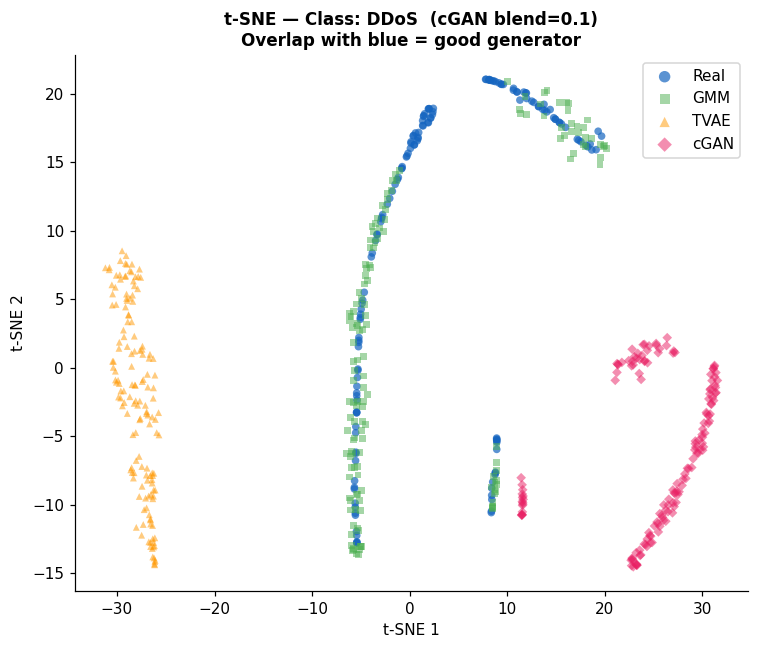

In [8]:
TSNE_CLASS = 'DDoS'   # ← change to whichever class you want to inspect
BLEND      = 0.1
N_TSNE     = 150      # keep small — t-SNE is slow

code     = [k for k, v in class_names.items() if v == TSNE_CLASS][0]
X_r_tsne = X_real[y_real == code][:N_TSNE]

parts = {'Real': X_r_tsne}
for name, X_g in [
    ('GMM',  gen_gmm(TSNE_CLASS, N_TSNE)),
    ('TVAE', gen_tvae(TSNE_CLASS, N_TSNE)),
    ('cGAN', gen_cgan(TSNE_CLASS, N_TSNE, BLEND)),
]:
    if X_g is not None:
        parts[name] = X_g

X_stack  = np.vstack(list(parts.values()))
labels_s = np.concatenate([[k]*len(v) for k, v in parts.items()])

print(f't-SNE on {len(X_stack)} samples for class "{TSNE_CLASS}"...')
tsne   = TSNE(n_components=2, random_state=42,
              perplexity=min(30, len(X_stack)//5), n_iter=500)
X_emb  = tsne.fit_transform(X_stack)
print('Done.')

colors  = {'Real': '#1565C0', 'GMM': '#4CAF50', 'TVAE': '#FF9800', 'cGAN': '#E91E63'}
markers = {'Real': 'o', 'GMM': 's', 'TVAE': '^', 'cGAN': 'D'}

fig, ax = plt.subplots(figsize=(7, 6))
for name in parts:
    mask = labels_s == name
    ax.scatter(X_emb[mask,0], X_emb[mask,1],
               c=colors[name], marker=markers[name],
               alpha=0.7 if name=='Real' else 0.5,
               s=25 if name=='Real' else 20,
               label=name, edgecolors='none')
ax.set_title(f't-SNE — Class: {TSNE_CLASS}  (cGAN blend={BLEND})\n'
             'Overlap with blue = good generator',
             fontsize=11, fontweight='bold')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(fontsize=10, markerscale=1.5)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 5. cGAN Blend Sweep — Finding the Sweet Spot

Blend 0.0 = pure GMM. Blend 1.0 = pure cGAN. Watch when metrics deteriorate.

Blend sweep for class: DDoS

 blend       MAE   Pearson r   Wasserstein
--------------------------------------------
  0.00   0.00941      0.9954       0.01021  ✅
  0.05   0.02318      0.9928       0.02330  ✅
  0.10   0.03697      0.9856       0.03704  ✅
  0.15   0.05075      0.9726       0.05082  
  0.20   0.06454      0.9527       0.06460  
  0.30   0.09211      0.8886       0.09217  
  0.50   0.14726      0.6645       0.14730  
  0.70   0.20240      0.3887       0.20244  
  1.00   0.28512      0.0664       0.28515  


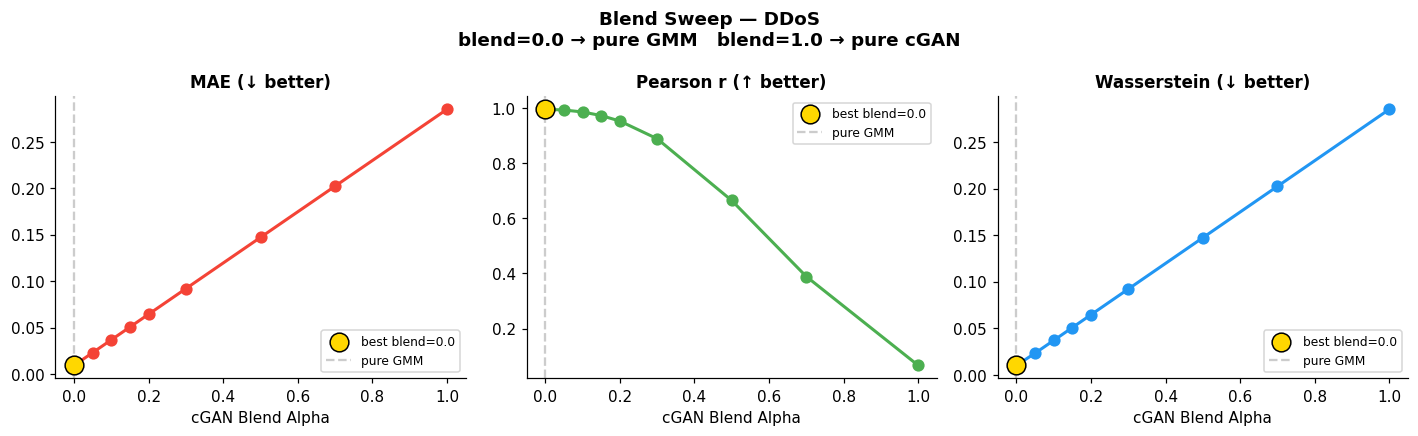


📌 Recommendation: keep blend ≤ 0.1 unless metrics stay green.


In [9]:
SWEEP_CLASS = 'DDoS'   # ← pick any class with decent real sample count
BLENDS      = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 0.7, 1.0]

code   = [k for k, v in class_names.items() if v == SWEEP_CLASS][0]
X_r    = X_real[y_real == code][:5000]

if not cgan_ok:
    print('cGAN not loaded — skipping blend sweep')
else:
    sweep_mae, sweep_r, sweep_ws = [], [], []
    print(f'Blend sweep for class: {SWEEP_CLASS}\n')
    print(f'{"blend":>6}  {"MAE":>8}  {"Pearson r":>10}  {"Wasserstein":>12}')
    print('-'*44)
    for bl in BLENDS:
        X_g = gen_cgan(SWEEP_CLASS, N, bl)
        m   = metrics(X_r, X_g)
        sweep_mae.append(m['mae']); sweep_r.append(m['r']); sweep_ws.append(m['ws'])
        ok = '✅' if m['mae']<0.05 and m['r']>0.85 else ''
        print(f'{bl:>6.2f}  {m["mae"]:>8.5f}  {m["r"]:>10.4f}  {m["ws"]:>12.5f}  {ok}')

    # Quick plot
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, vals, title, col, lower in [
        (axes[0], sweep_mae, 'MAE (↓ better)',      '#F44336', True),
        (axes[1], sweep_r,   'Pearson r (↑ better)','#4CAF50', False),
        (axes[2], sweep_ws,  'Wasserstein (↓ better)','#2196F3',True),
    ]:
        ax.plot(BLENDS, vals, 'o-', color=col, lw=2, ms=7)
        best = np.argmin(vals) if lower else np.argmax(vals)
        ax.scatter([BLENDS[best]], [vals[best]], s=150, color='gold',
                   zorder=5, edgecolors='black', label=f'best blend={BLENDS[best]}')
        ax.axvline(0, color='gray', ls='--', alpha=0.4, label='pure GMM')
        ax.set_xlabel('cGAN Blend Alpha'); ax.set_title(title, fontweight='bold')
        ax.legend(fontsize=8)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    plt.suptitle(f'Blend Sweep — {SWEEP_CLASS}\n'
                 'blend=0.0 → pure GMM   blend=1.0 → pure cGAN',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'\n📌 Recommendation: keep blend ≤ 0.1 unless metrics stay green.')

## 6. Mode Comparison — stream / attack / adversarial

In [10]:
from gateway.gateway import Gateway
import torch

ATTACK = attack_classes[0] if attack_classes else 'DDoS'
BLEND  = 0.1
N_MODE = 500

X_real_atk = X_real[y_real > 0]   # real attack samples (reference)

# ── Load BiGAN for adversarial mode ──────────────────────────────────────────
bigan_obj = None
try:
    from models.bigan_model import BiGAN
    ckpt  = torch.load('bigan_final.pth', map_location='cpu')
    bigan_obj = BiGAN(ckpt['input_dim'], latent_dim=8)
    bigan_obj.load_state_dict(ckpt['state_dict'])
    bigan_obj.eval()
    print('BiGAN loaded for adversarial mode ✅')
except Exception as e:
    print(f'BiGAN not found — adversarial mode will be skipped: {e}')

GENS = [('GMM', 'none'), ('TVAE', 'tvae'), ('cGAN', 'cgan')]

print(f'\n{"─"*70}')
print(f'{"Mode":<14} {"Generator":<8}  Metrics (vs real attack distribution)')
print(f'{"─"*70}')

mode_pca = {}  # for PCA subplot later

for mode in ['stream', 'attack', 'adversarial']:
    for gen_label, gen_type in GENS:
        try:
            gw = Gateway(generator_type=gen_type, gan_blend_alpha=BLEND,
                         epsilon=0.15)
            ids_obj = bigan_obj if (mode == 'adversarial' and bigan_obj) else None
            X_g, y_g, _ = gw.generate(
                mode=mode, n_samples=N_MODE,
                attack_type=ATTACK if mode in ('attack','adversarial') else None,
                ids_model=ids_obj, model_type='bigan'
            )
            X_atk = X_g[y_g > 0]
            m = metrics(X_real_atk, X_atk) if len(X_atk) > 5 else None
            mode_pca[(mode, gen_label)] = (X_g, y_g)
            print(f'{mode:<14} {gen_label:<8}  {fmt(m)}')
        except Exception as e:
            print(f'{mode:<14} {gen_label:<8}  ERROR: {e}')
    print()

print('✅ = good  ⚠️ = marginal  ❌ = needs attention')

Gateway | INFO | Robust calibration loaded: flip=True
GMMGenerator | INFO | GMM loaded | classes: ['Benign', 'C&C-HeartBeat', 'DDoS', 'Okiru', 'PartOfAHorizontalPortScan']
Gateway | INFO | GMM-only mode.
Gateway | INFO | Gateway ready | classes=5 | GMM+GAN=False | blend_α=0.1 | ε=0.150
Gateway | INFO | Stream mode | n=500 | benign_ratio=70%


BiGAN loaded for adversarial mode ✅

──────────────────────────────────────────────────────────────────────
Mode           Generator  Metrics (vs real attack distribution)
──────────────────────────────────────────────────────────────────────


Gateway | INFO | Robust calibration loaded: flip=True
GMMGenerator | INFO | GMM loaded | classes: ['Benign', 'C&C-HeartBeat', 'DDoS', 'Okiru', 'PartOfAHorizontalPortScan']
LoadTVAE | INFO | TVAE loaded | features=39 | classes=5 | latent=32
Gateway | INFO | Generator 'tvae' loaded — hybrid mode active (dim=39).
Gateway | INFO | Gateway ready | classes=5 | GMM+GAN=True | blend_α=0.1 | ε=0.150
Gateway | INFO | Stream mode | n=500 | benign_ratio=70%


stream         GMM       MAE=0.0208✅  r=0.9940✅  WS=0.0236✅


Gateway | INFO | Robust calibration loaded: flip=True
GMMGenerator | INFO | GMM loaded | classes: ['Benign', 'C&C-HeartBeat', 'DDoS', 'Okiru', 'PartOfAHorizontalPortScan']
GatewayUtils | INFO | cGAN loaded | features=39 | classes=5
Gateway | INFO | Generator 'cgan' loaded — hybrid mode active (dim=39).
Gateway | INFO | Gateway ready | classes=5 | GMM+GAN=True | blend_α=0.1 | ε=0.150
Gateway | INFO | Stream mode | n=500 | benign_ratio=70%


...

attack         cGAN      MAE=0.0680⚠️  r=0.9363✅  WS=0.0755⚠️



Gateway | INFO | Robust calibration loaded: flip=True
GMMGenerator | INFO | GMM loaded | classes: ['Benign', 'C&C-HeartBeat', 'DDoS', 'Okiru', 'PartOfAHorizontalPortScan']
LoadTVAE | INFO | TVAE loaded | features=39 | classes=5 | latent=32
Gateway | INFO | Generator 'tvae' loaded — hybrid mode active (dim=39).
Gateway | INFO | Gateway ready | classes=5 | GMM+GAN=True | blend_α=0.1 | ε=0.150
Gateway | INFO | Adversarial mode | type=C&C-HeartBeat | model=bigan | n=500 | ε=0.150
Gateway | INFO | FGSM | model_type=bigan | ε=0.150 | n=500


adversarial    GMM       MAE=0.1857❌  r=0.8897✅  WS=0.1879❌


Gateway | INFO | Robust calibration loaded: flip=True
GMMGenerator | INFO | GMM loaded | classes: ['Benign', 'C&C-HeartBeat', 'DDoS', 'Okiru', 'PartOfAHorizontalPortScan']
GatewayUtils | INFO | cGAN loaded | features=39 | classes=5
Gateway | INFO | Generator 'cgan' loaded — hybrid mode active (dim=39).
Gateway | INFO | Gateway ready | classes=5 | GMM+GAN=True | blend_α=0.1 | ε=0.150
Gateway | INFO | Adversarial mode | type=C&C-HeartBeat | model=bigan | n=500 | ε=0.150
Gateway | INFO | FGSM | model_type=bigan | ε=0.150 | n=500


adversarial    TVAE      MAE=0.1889❌  r=0.8831✅  WS=0.1912❌
adversarial    cGAN      MAE=0.1927❌  r=0.8823✅  WS=0.1949❌

✅ = good  ⚠️ = marginal  ❌ = needs attention


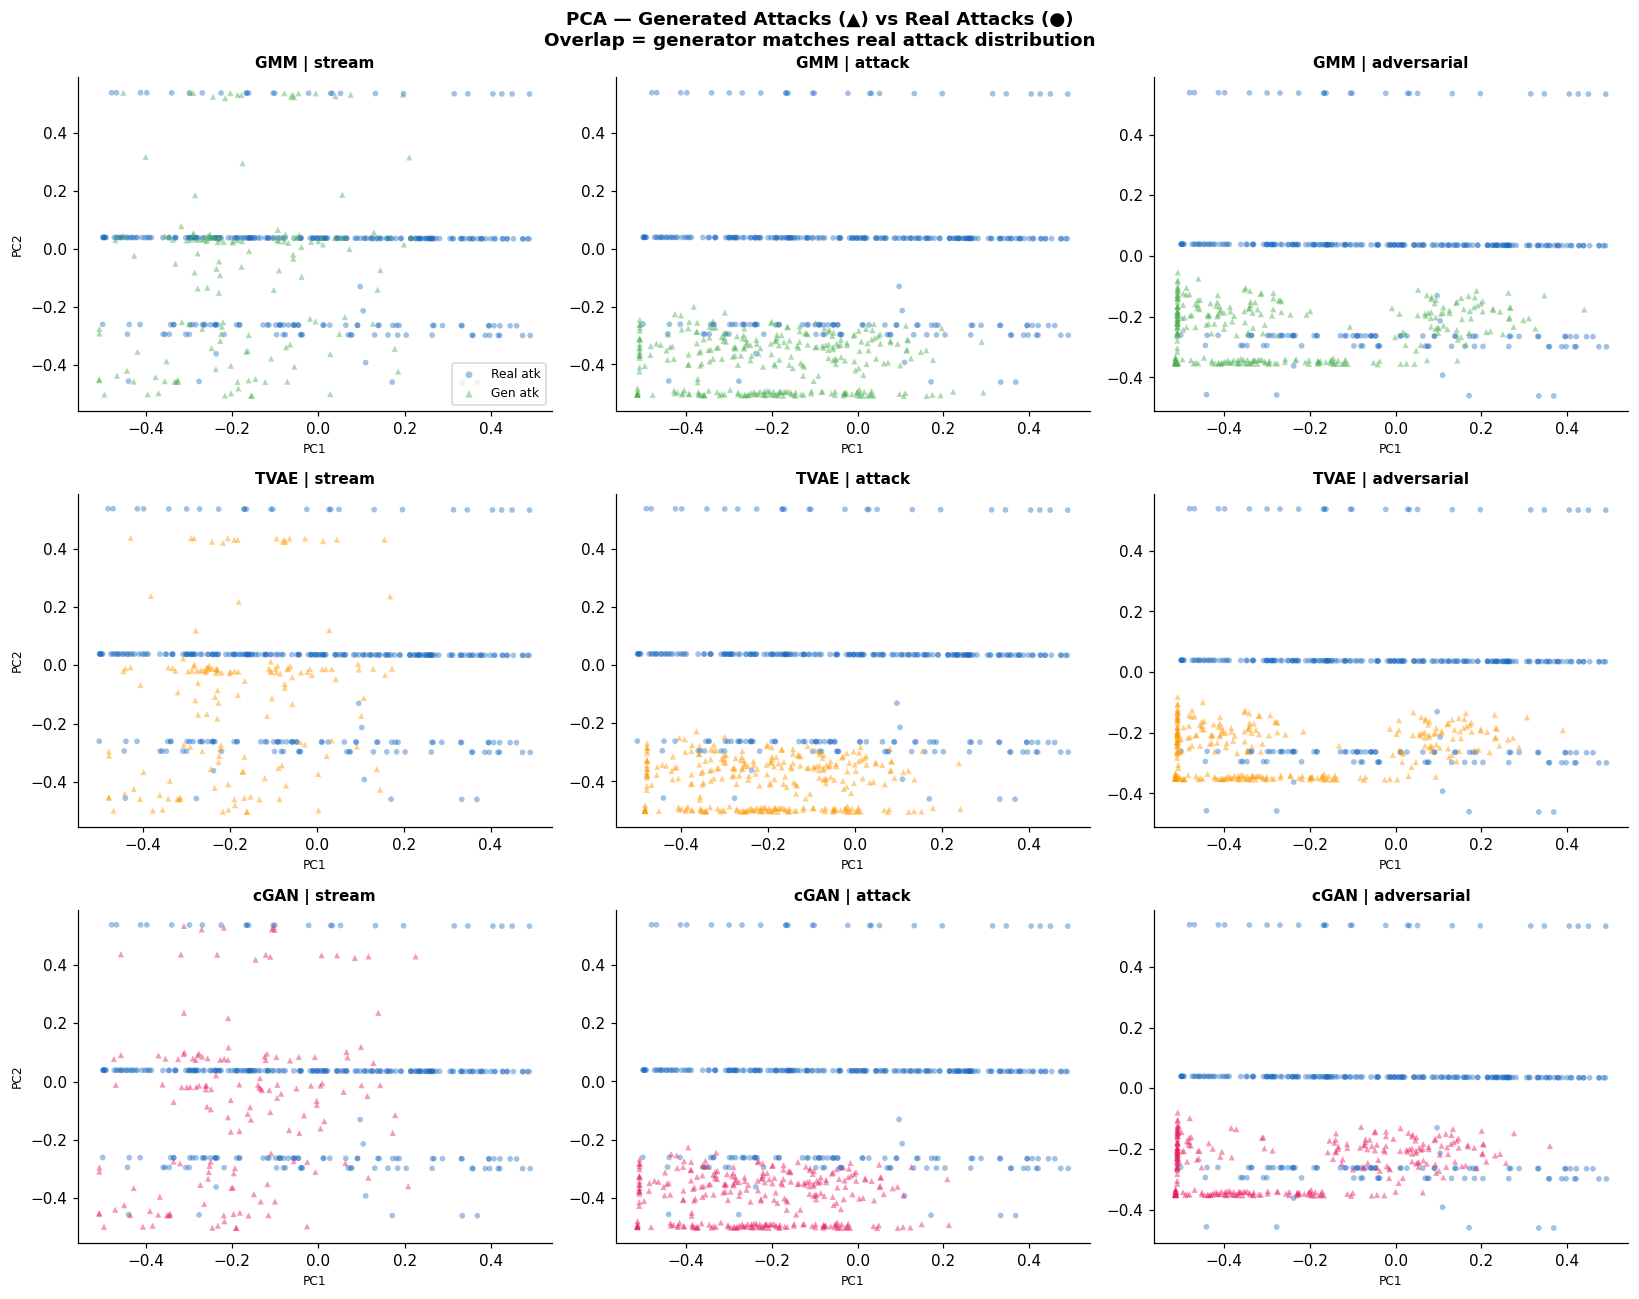

In [11]:
# PCA: mode × generator grid
modes = ['stream', 'attack', 'adversarial']
gen_labels_plot = ['GMM', 'TVAE', 'cGAN']
gen_colors_plot = ['#4CAF50', '#FF9800', '#E91E63']

Xra_pca = pca.transform(X_real_atk[:N_VIZ])

fig, axes = plt.subplots(len(gen_labels_plot), len(modes),
                         figsize=(5*len(modes), 4*len(gen_labels_plot)),
                         squeeze=False)

for gi, (gen_label, col) in enumerate(zip(gen_labels_plot, gen_colors_plot)):
    for mi, mode in enumerate(modes):
        ax  = axes[gi][mi]
        key = (mode, gen_label)
        # Real attacks (blue)
        ax.scatter(Xra_pca[:,0], Xra_pca[:,1],
                   c='#1565C0', alpha=0.4, s=14, label='Real atk', edgecolors='none')
        if key in mode_pca:
            X_g, y_g = mode_pca[key]
            atk      = y_g > 0
            if atk.sum() > 0:
                Xg_pca = pca.transform(X_g[atk][:N_VIZ])
                ax.scatter(Xg_pca[:,0], Xg_pca[:,1],
                           c=col, alpha=0.45, s=16, marker='^',
                           label='Gen atk', edgecolors='none')
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes)

        ax.set_title(f'{gen_label} | {mode}', fontsize=10, fontweight='bold')
        ax.set_xlabel('PC1', fontsize=8)
        if mi == 0: ax.set_ylabel('PC2', fontsize=8)
        if gi == 0 and mi == 0:
            ax.legend(fontsize=8, markerscale=1.2)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('PCA — Generated Attacks (▲) vs Real Attacks (●)\n'
             'Overlap = generator matches real attack distribution',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Mean Bar — What's Actually Different?

Top-10 features where generated mean deviates most from real.

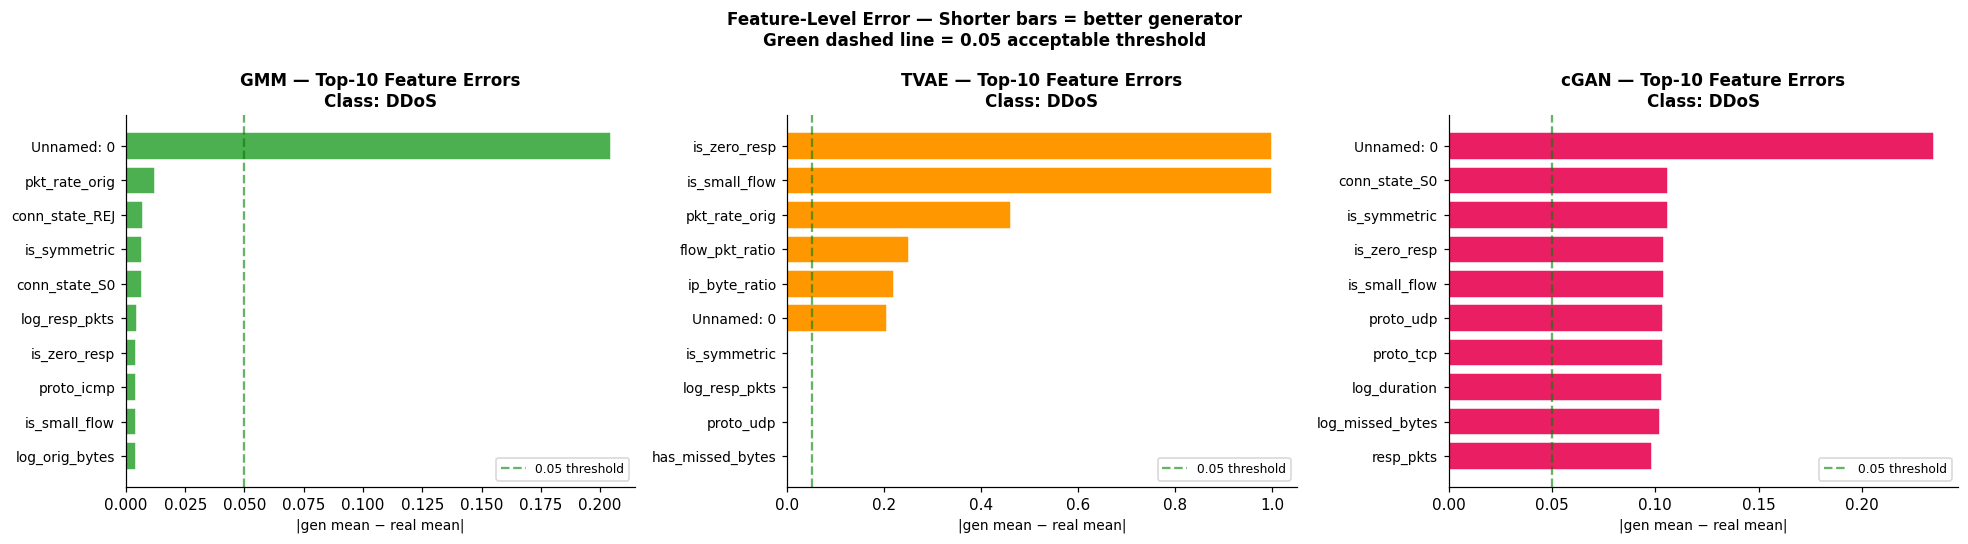

Features to the right of the green line are the main divergence drivers.


In [12]:
CHECK_CLASS = 'DDoS'   # ← adjust
BLEND       = 0.1

code  = [k for k, v in class_names.items() if v == CHECK_CLASS][0]
X_r   = X_real[y_real == code][:5000]
r_mean = X_r.mean(0)

gens_bar = [
    ('GMM',  gen_gmm(CHECK_CLASS),         '#4CAF50'),
    ('TVAE', gen_tvae(CHECK_CLASS),        '#FF9800'),
    ('cGAN', gen_cgan(CHECK_CLASS, blend=BLEND), '#E91E63'),
]

fig, axes = plt.subplots(1, len([g for g in gens_bar if g[1] is not None]),
                         figsize=(6*len(gens_bar), 5), squeeze=False)

ai = 0
for gen_name, X_g, col in gens_bar:
    if X_g is None: continue
    diff = np.abs(X_g.mean(0) - r_mean)
    top10 = np.argsort(diff)[-10:][::-1]
    ax = axes[0][ai]
    ax.barh(range(10), diff[top10], color=col, edgecolor='white')
    ax.set_yticks(range(10))
    ax.set_yticklabels([feat_cols[i][:20] for i in top10], fontsize=9)
    ax.set_xlabel('|gen mean − real mean|', fontsize=9)
    ax.set_title(f'{gen_name} — Top-10 Feature Errors\nClass: {CHECK_CLASS}',
                 fontweight='bold')
    ax.axvline(0.05, color='green', ls='--', alpha=0.6, label='0.05 threshold')
    ax.legend(fontsize=8)
    ax.invert_yaxis()
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ai += 1

plt.suptitle(f'Feature-Level Error — Shorter bars = better generator\n'
             f'Green dashed line = 0.05 acceptable threshold',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
print('Features to the right of the green line are the main divergence drivers.')

---
## Summary

| What to look for | Good sign | Bad sign |
|---|---|---|
| PCA / t-SNE | Blue and coloured overlap | Separate blobs |
| MAE | < 0.05 | > 0.10 |
| Pearson r | > 0.85 | < 0.70 |
| Wasserstein | < 0.05 | > 0.10 |
| Feature bar | All bars short | Long bars = specific features broken |

**Based on your results:** GMM is the strongest baseline (MAE≈0.012, r≈0.995). The cGAN/TVAE add noise at high blend values — keep blend ≤ 0.1.